# Module 9 · 圖像 1：經典影像特徵（快速帶過）

> **本節定位｜快速帶過（經典基礎）**
> 色彩直方圖、HOG 是深度學習普及前（~2005–2015）的**手工影像特徵**。
> 它們仍有助於建立「如何把像素變成特徵」的直覺，但 **2026 主流是用
> 預訓練視覺模型（ViT/CLIP）自動學特徵**（下一節起）。本節快速體驗即可。

## 學習目標
- 理解影像在電腦中的本質：**像素張量**。
- 用 **色彩直方圖** 與 **HOG** 兩種經典手工特徵，把影像變成固定長度向量。
- 認識手工特徵的限制（不具語意、對視角/光照敏感），理解為何被學習式特徵取代。

<!-- concept-image:01_classical_image_features_fig1 -->
<div align="center">
<img src="concept_images/01_classical_image_features_fig1_tensor_structure_20260611_220948.png" alt="像素到向量：影像的三維張量結構" width="640" style="max-width:100%;">
<br><sub>圖 1 · 像素到向量：影像的三維張量結構</sub>
</div>

In [30]:
# 解決 matplotlib 中文顯示 UserWarning 問題
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS', 'SimHei', 'Arial']  # 根據作業系統可調整
matplotlib.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

In [31]:
import numpy as np
from PIL import Image
from sklearn.datasets import load_sample_images

# 使用 scikit-learn 內建的真實照片（無需額外下載）：flower.jpg
img = load_sample_images().images[1]          # 一張真實的花朵照片 (H, W, C)
pil_img = Image.fromarray(img.astype(np.uint8))
print(f"真實影像（sklearn load_sample_images: flower）")
print(f"影像張量形狀 = {img.shape}  (H, W, C) ← numpy/PIL 慣例")
print(f"像素值域 = [{img.min()}, {img.max()}]  dtype = {img.dtype}")

真實影像（sklearn load_sample_images: flower）
影像張量形狀 = (427, 640, 3)  (H, W, C) ← numpy/PIL 慣例
像素值域 = [0, 255]  dtype = uint8


R 通道 shape: (427, 640)
G 通道 shape: (427, 640)
B 通道 shape: (427, 640)


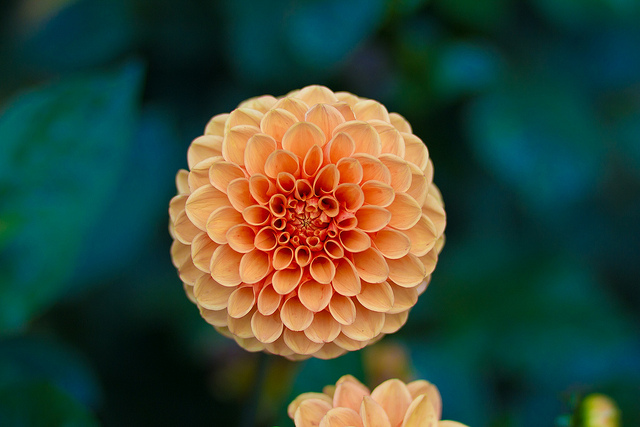

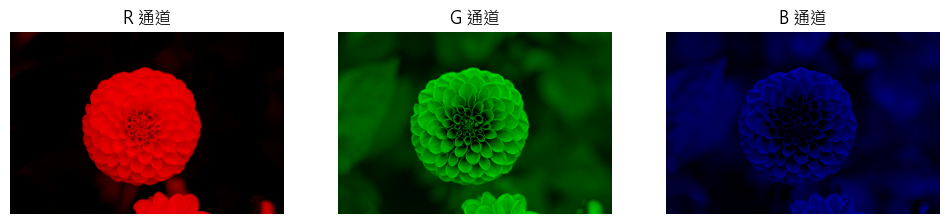

In [32]:

Image.fromarray(img)

# R、G、B 通道分別擷取為獨立的2D陣列
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]
print("R 通道 shape:", R.shape)
print("G 通道 shape:", G.shape)
print("B 通道 shape:", B.shape)

display(pil_img)

# 個別顯示 R G B 通道為影像

import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
channels = [R, G, B]
titles = ['R', 'G', 'B']
for i, (ch, title) in enumerate(zip(channels, titles)):
    # 為了顯示效果，把單通道堆疊為三通道
    rgb_img = np.zeros_like(img)
    rgb_img[:, :, i] = ch
    axs[i].imshow(rgb_img)
    axs[i].set_title(f"{title} 通道")
    axs[i].axis('off')
plt.show()

## 1. 色彩直方圖 (Color Histogram)

統計每個顏色通道的像素強度分佈，串接成一個向量。**對平移/旋轉穩健，但完全丟失空間結構**。

色彩直方圖特徵維度 = (48,)  (3 通道 × 16 bins = 48)
→ 不論影像多大，都壓成固定長度向量；但『花在哪個位置』這類空間資訊完全消失。


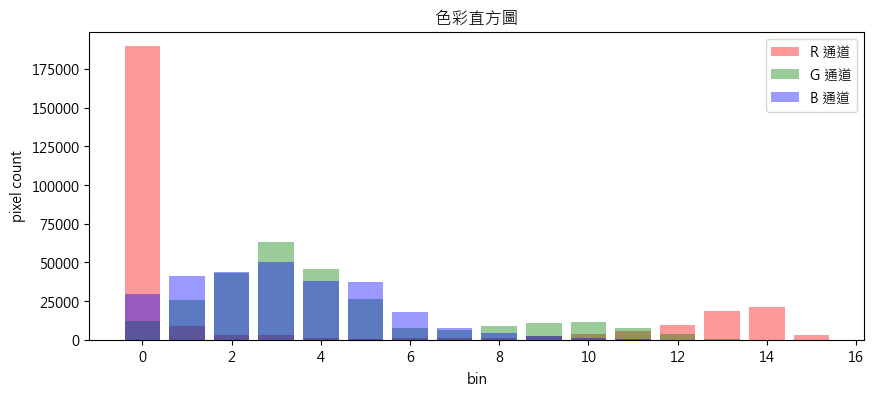

In [33]:
def color_histogram(arr, bins=16):
    feats = []
    for ch in range(3):                       # R, G, B 三通道
        hist, _ = np.histogram(arr[:, :, ch], bins=bins, range=(0, 255))
        feats.append(hist)
    return np.concatenate(feats).astype(float)

hist_vec = color_histogram(img, bins=16)
print(f"色彩直方圖特徵維度 = {hist_vec.shape}  (3 通道 × 16 bins = 48)")
print("→ 不論影像多大，都壓成固定長度向量；但『花在哪個位置』這類空間資訊完全消失。")

# hist_vec 視覺化
plt.figure(figsize=(10,4))
channel_colors = ['red', 'green', 'blue']
bins = 16  # 與上方 color_histogram 相同
for i in range(3):
    start = i*bins
    end = (i+1)*bins
    # 直方圖視覺化（棒狀圖）
    plt.bar(range(bins), hist_vec[start:end], alpha=0.4, color=channel_colors[i], label=f'{titles[i]} 通道')
    # plt.plot(range(bins), hist_vec[start:end], label=f'{titles[i]} 通道', color=channel_colors[i])
    
plt.xlabel('bin')
plt.ylabel('pixel count')
plt.title('色彩直方圖')
plt.legend()
plt.show()

## 2. HOG (Histogram of Oriented Gradients)

統計局部區域的「梯度方向分佈」，能捕捉**邊緣/形狀**，曾是行人偵測的經典特徵。
需要 `classical` extra：`uv sync --extra classical`。

<!-- concept-image:01_classical_image_features_fig2 -->
<div align="center">
<img src="concept_images/01_classical_image_features_fig2_histograms_hog_20260611_182928.png" alt="色彩直方圖 vs HOG 對比" width="640" style="max-width:100%;">
<br><sub>圖 2 · 色彩直方圖 vs HOG 對比</sub>
</div>

HOG 特徵維度 = (35100,)
→ 捕捉了邊緣方向（左右交界的垂直邊緣會有明顯響應）。


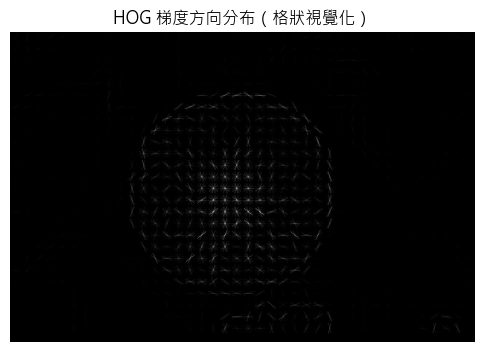

In [36]:
try:
    from skimage.feature import hog
    from skimage.color import rgb2gray
    gray = rgb2gray(img)
    hog_vec = hog(gray, orientations=9, pixels_per_cell=(16, 16),
                  cells_per_block=(2, 2), feature_vector=True)

    print(f"HOG 特徵維度 = {hog_vec.shape}")
    print("→ 捕捉了邊緣方向（左右交界的垂直邊緣會有明顯響應）。")

    # HOG 特徵視覺化：以格狀方式顯示每個 cell 的方向直方圖
    from skimage import exposure

    # 重組 hog 的 "visualization" 圖示
    _, hog_image = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        feature_vector=True,
        visualize=True
    )

    # 增強對比，利於視覺化
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

    plt.figure(figsize=(6, 6))
    plt.imshow(hog_image_rescaled, cmap="gray")
    plt.title("HOG 梯度方向分布（格狀視覺化）")
    plt.axis('off')
    plt.show()
    
except Exception as e:
    print("（未安裝 scikit-image，略過實際計算）", e)
    print("概念：把影像切成小格，統計每格的梯度方向直方圖，串接成特徵；擅長描述形狀/邊緣。")


## 3. 手工特徵的限制 → 為何 2026 改用學習式特徵

| 面向 | 手工特徵（本節） | 學習式特徵（下一節 ViT/CLIP） |
|:--|:--|:--|
| 特徵來源 | 人類設計規則（顏色統計、梯度） | 模型在海量影像上**自己學** |
| 語意 | 無（只看低階統計） | 有（能分辨貓/狗/物件/場景） |
| 穩健性 | 對視角、光照、形變敏感 | 大幅較穩健 |
| 通用性 | 換任務常要重新設計 | 一個預訓練模型可遷移到多任務 |

**結論**：手工特徵幫助理解「像素→向量」，但要餵 2026 的模型，
我們需要把影像**正確地變成張量**（下一節），再交給預訓練視覺模型抽特徵。

---
### 小結
- 影像 = 像素張量 `(H, W, C)`。
- 色彩直方圖：固定長度、丟空間資訊；HOG：捕捉邊緣形狀。
- 兩者皆無語意、對變形敏感 → 被 ViT/CLIP 等學習式特徵取代。

<!-- concept-image:01_classical_image_features_fig3 -->
<div align="center">
<img src="concept_images/01_classical_image_features_fig3_feature_evolution_20260611_221024.png" alt="手工特徵 vs 學習式特徵對比" width="640" style="max-width:100%;">
<br><sub>圖 3 · 手工特徵 vs 學習式特徵對比</sub>
</div>